In [27]:
# Exercise 1: Creating Networks from Data

In [28]:
# Load relevant libraries
# Extensive documentation for iGraph here: http://igraph.org/r/doc/
suppressMessages(library(igraph))

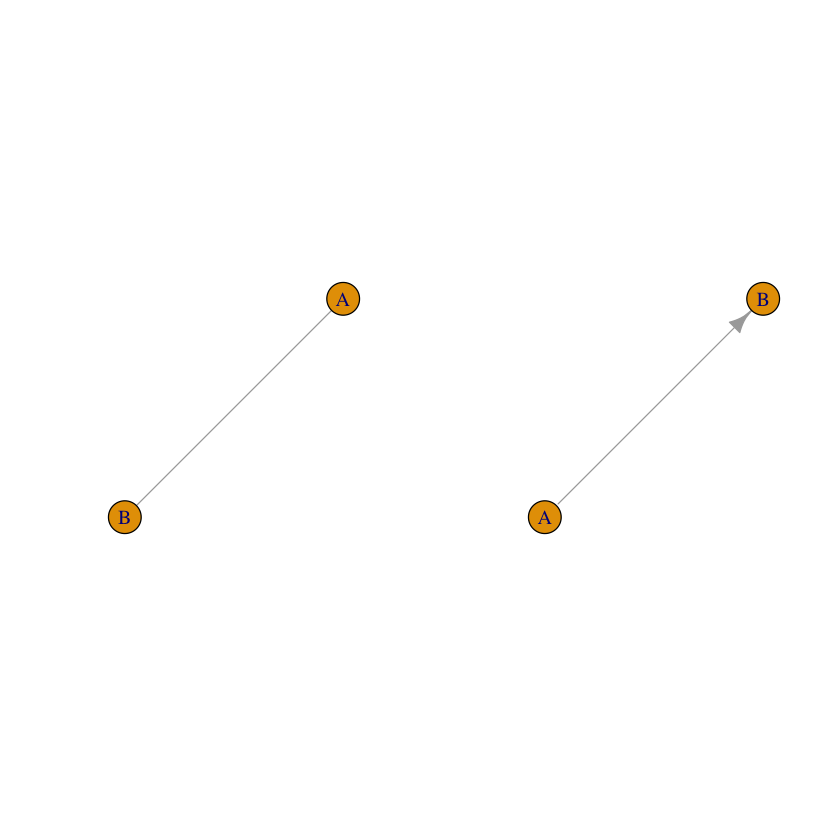

In [29]:
# Build a network using basic formulas:
graph.onelinkUnD <- graph.formula(A-B)
graph.onelinkD <- graph.formula(A-+B) 
# With this function the (+) sign signifies the "arrowhead".

# This gives us a two node network with one edge. 
par(mfrow=c(1,2)) # This is a plotting command that says to plot in a
                  # 1 row, 2 column grid so we can view plots side by side
plot.igraph(graph.onelinkUnD, vertex.size=30)
plot.igraph(graph.onelinkD, vertex.size=30)

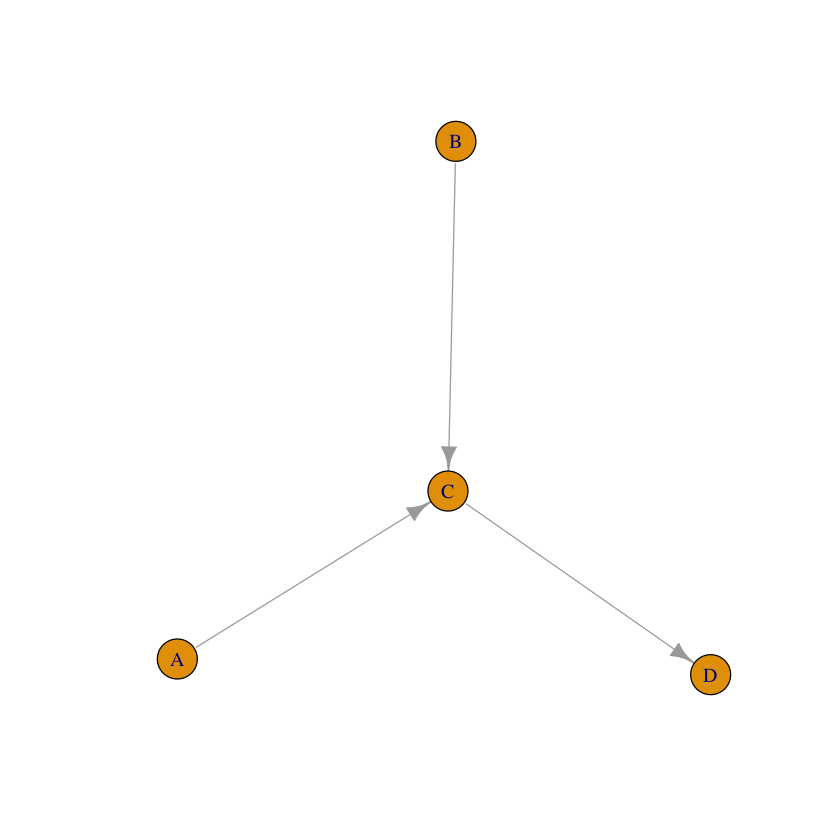

In [30]:
# Using graph.formula() you have to write out all edges explicitly
graph.fournode<-graph.formula(A-+C,B-+C,C-+D)
plot.igraph(graph.fournode)

In [31]:
# Can you plot the 6 node network from the lecture?

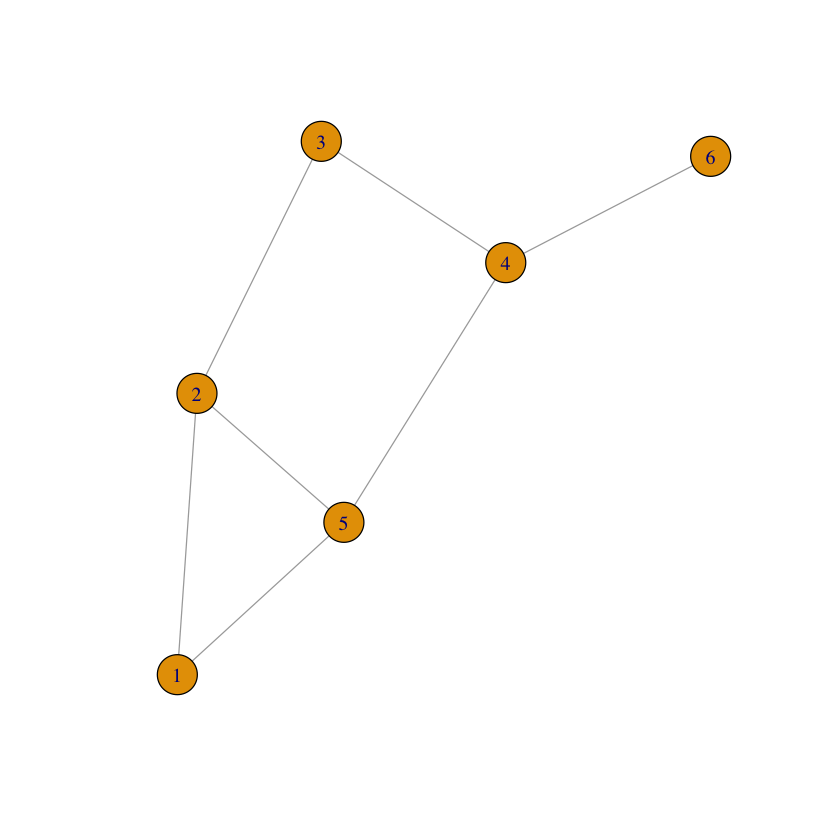

In [32]:
graph.sixnode<-graph.formula(1-1,1-2,1-5,2-5,2-3,3-4,5-4,4-6)
plot.igraph(graph.sixnode) # No self loop?

In [33]:
# Check the adjacency matrix
gsixadj<-get.adjacency(graph.sixnode)
gsixadj

6 x 6 sparse Matrix of class "dgCMatrix"
  1 2 5 3 4 6
1 . 1 1 . . .
2 1 . 1 1 . .
5 1 1 . . 1 .
3 . 1 . . 1 .
4 . . 1 1 . 1
6 . . . . 1 .

6 x 6 sparse Matrix of class "dgCMatrix"
  1 2 5 3 4 6
1 1 1 1 . . .
2 1 . 1 1 . .
5 1 1 . . 1 .
3 . 1 . . 1 .
4 . . 1 1 . 1
6 . . . . 1 .

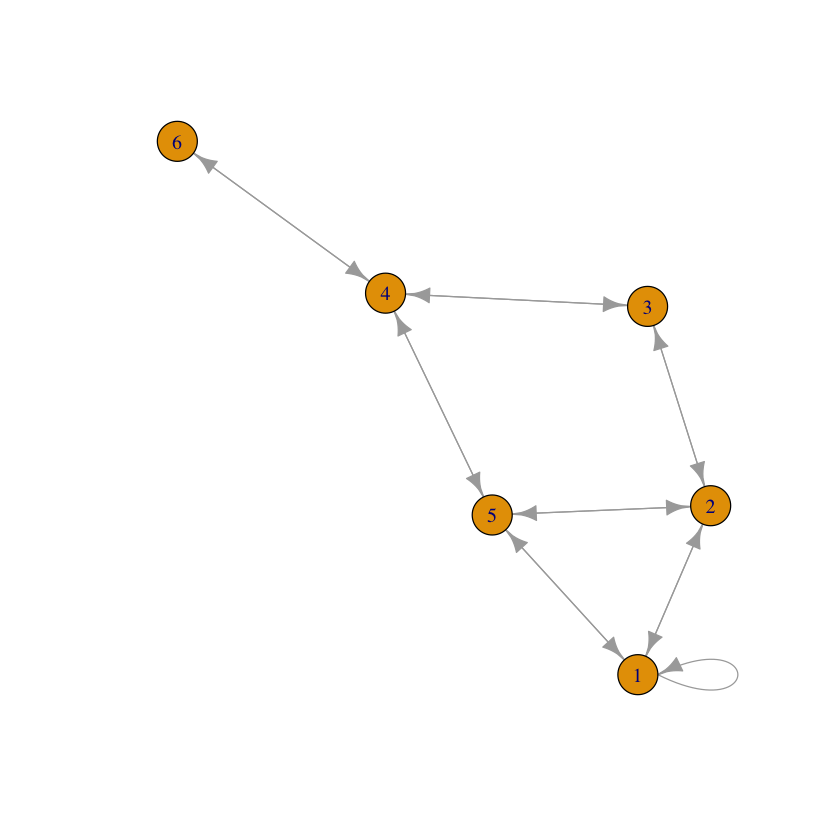

In [34]:
gsixadj[1,1] <- 1
gsixadj
plot.igraph(graph_from_adjacency_matrix(gsixadj))

In [35]:
?graph_from_adjacency_matrix

graph_from_adjacency_matrix {igraph},R Documentation
adjmatrix,A square adjacency matrix. From igraph version 0.5.1 this can be a sparse matrix created with the Matrix package.
mode,"Character scalar, specifies how igraph should interpret the supplied matrix. See also the weighted argument, the interpretation depends on that too. Possible values are: directed, undirected, upper, lower, max, min, plus. See details below."
weighted,This argument specifies whether to create a weighted graph from an adjacency matrix. If it is NULL then an unweighted graph is created and the elements of the adjacency matrix gives the number of edges between the vertices. If it is a character constant then for every non-zero matrix entry an edge is created and the value of the entry is added as an edge attribute named by the weighted argument. If it is TRUE then a weighted graph is created and the name of the edge attribute will be weight. See also details below.
diag,"Logical scalar, whether to include the diagonal of the matrix in the calculation. If this is FALSE then the diagonal is zerod out first."
add.colnames,"Character scalar, whether to add the column names as vertex attributes. If it is ‘NULL’ (the default) then, if present, column names are added as vertex attribute ‘name’. If ‘NA’ then they will not be added. If a character constant, then it gives the name of the vertex attribute to add."
add.rownames,"Character scalar, whether to add the row names as vertex attributes. Possible values the same as the previous argument. By default row names are not added. If ‘add.rownames’ and ‘add.colnames’ specify the same vertex attribute, then the former is ignored."
...,Passed to graph_from_adjacency_matrix().


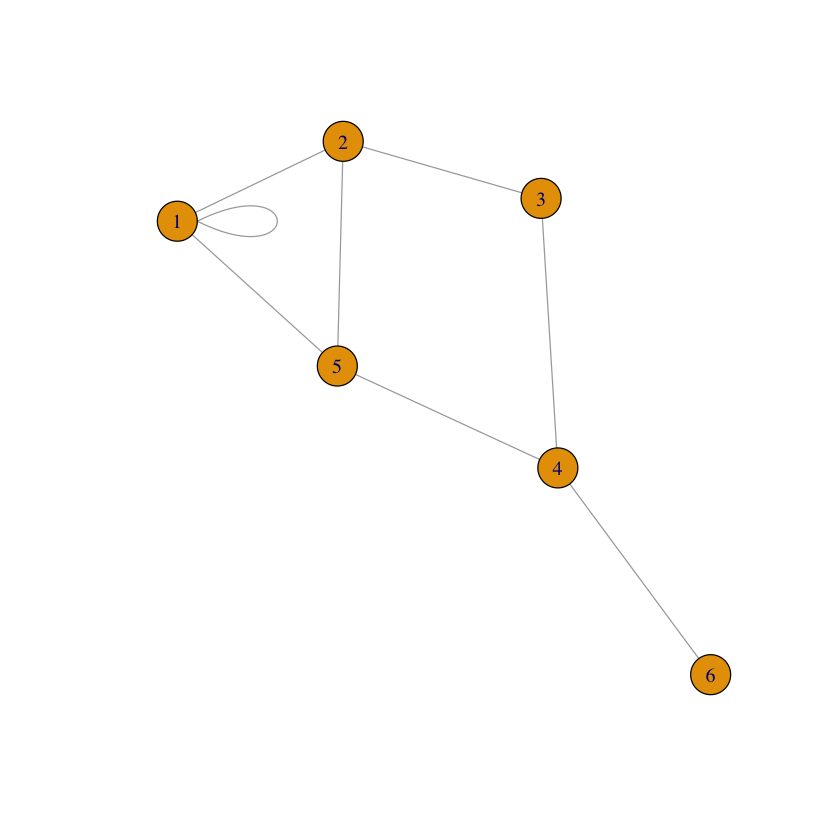

In [36]:
# Default is directed. We want an undirected graph - look at the mode parameter
plot.igraph(graph_from_adjacency_matrix(gsixadj,mode=c("undirected")))

In [37]:
# How about the bipartite network? 
# First we need to create the corresponding incidence matrix
m <- rbind(c(1,0,1),c(1,1,0),c(0,0,1))
m <- as.matrix(m)
rownames(m) <- c("1","2","3")
colnames(m) <- c("A","B","C")
m

,A,B,C
1,1,0,1
2,1,1,0
3,0,0,1


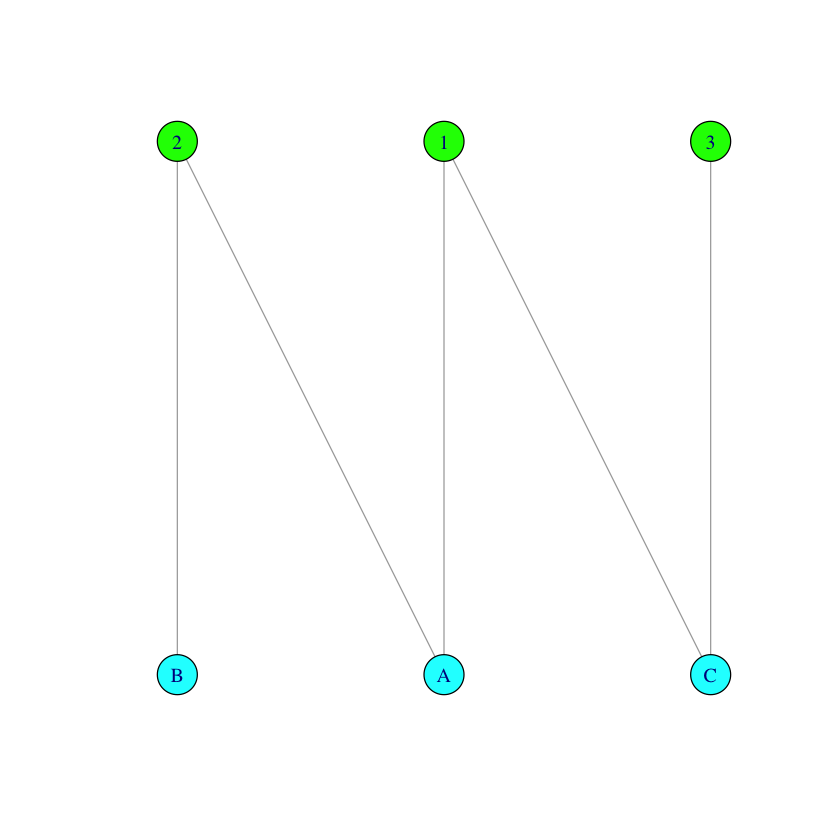

In [38]:
# Now create a graph from the incidence matrix
# and plot the graph using "layout=layout_as_bipartite"
g <- graph_from_incidence_matrix(m)
plot(g, layout = layout_as_bipartite,
     vertex.color=c("green","cyan")[V(g)$type+1])

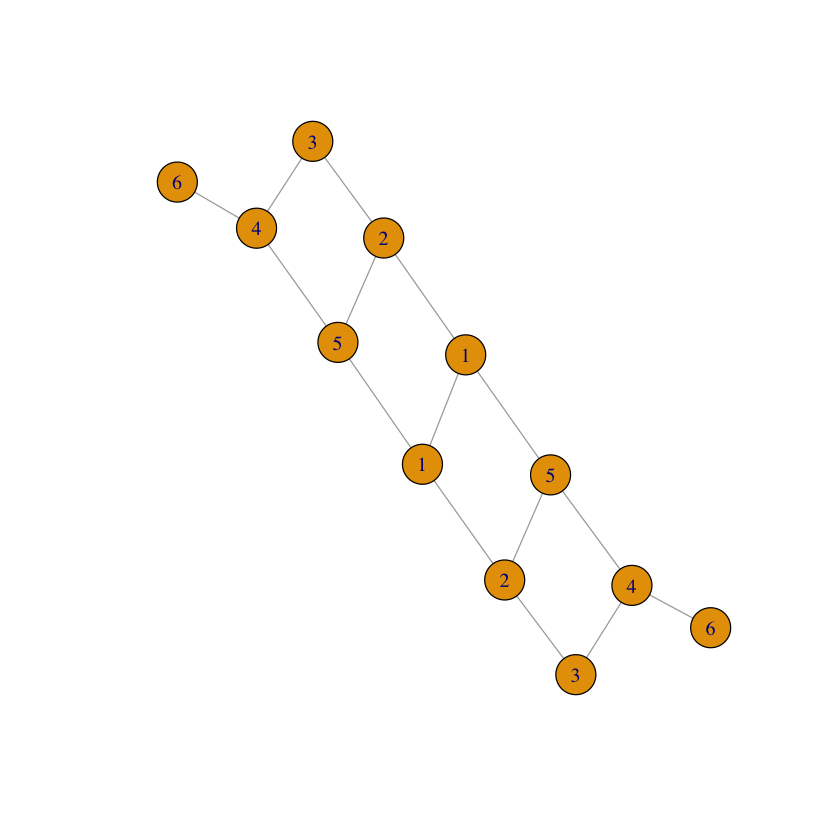

In [39]:
# What happens if we use our adjacency matrix from the first graph as 
# an incidence matrix for an undirected graph?
bipartite <- graph_from_incidence_matrix(gsixadj)
plot.igraph(bipartite)


In [40]:
# Creating networks manually is not practical
# Better to load them from a file
sdata <- read.table(file="SimpleNet.tsv",h=T)
head(sdata)

,NodeA,NodeB
,<int>,<int>
1,1,1
2,1,2
3,1,5
4,2,5
5,2,3
6,3,4


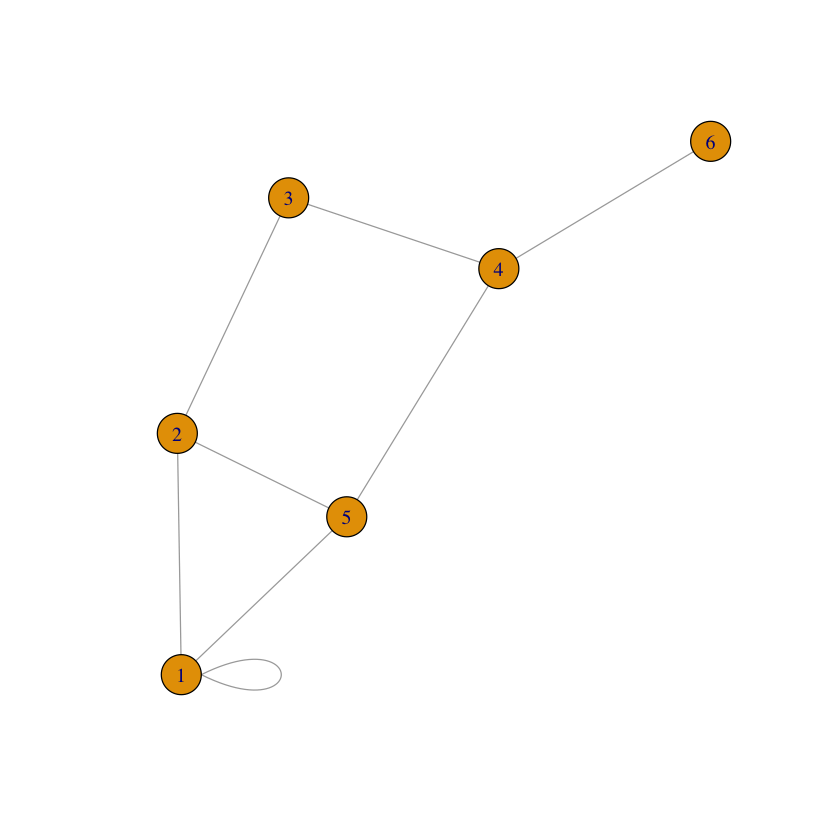

In [41]:
g <- graph.data.frame(sdata, directed=F)
plot.igraph(g)

In [42]:
sbdata <- read.table(file="SimpleBipartite.tsv",h=T)
head(sbdata)

,NodeA,NodeB
,<int>,<chr>
1,1,A
2,1,C
3,2,A
4,2,B
5,3,C


In [49]:
# Create a bipartite graph from an edge list instead of an incidence matrix
g <- graph.data.frame(sbdata, directed = F)
V(g)$type <- V(g)$name %in% sbdata[,2] # creates a boolean describing wether node is in column 2 or not
g

IGRAPH 932c2b0 UN-B 6 5 -- 
+ attr: name (v/c), type (v/l)
+ edges from 932c2b0 (vertex names):
[1] 1--A 1--C 2--A 2--B 3--C

In [55]:
# Convert boolean node label to a numerical index for plotting
V(g)$type
V(g)$type+1

[1] FALSE FALSE FALSE  TRUE  TRUE  TRUE

[1] 1 1 1 2 2 2

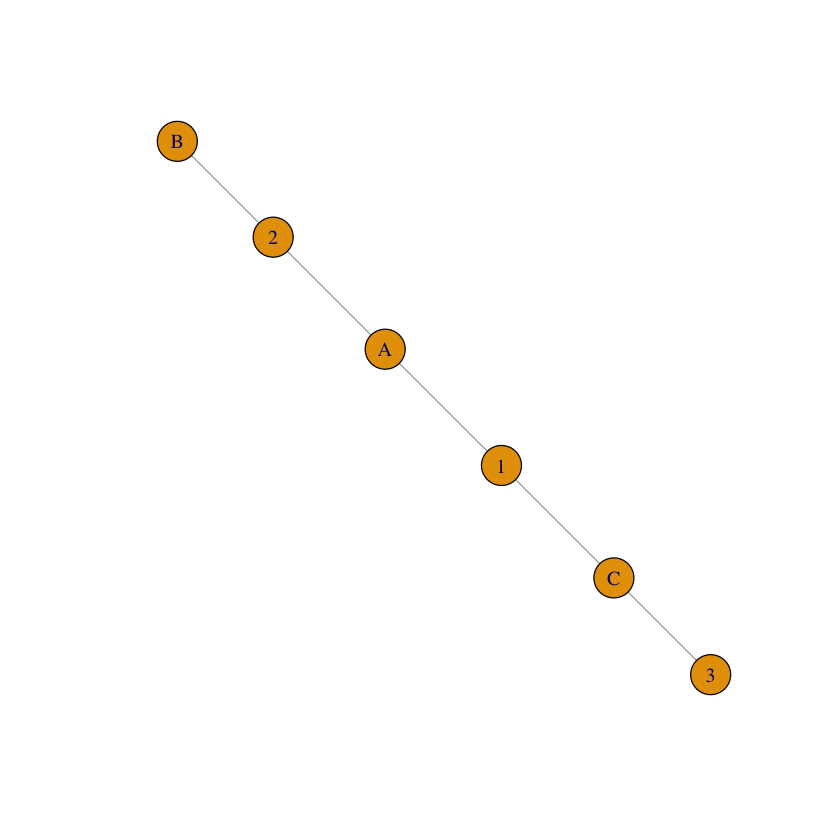

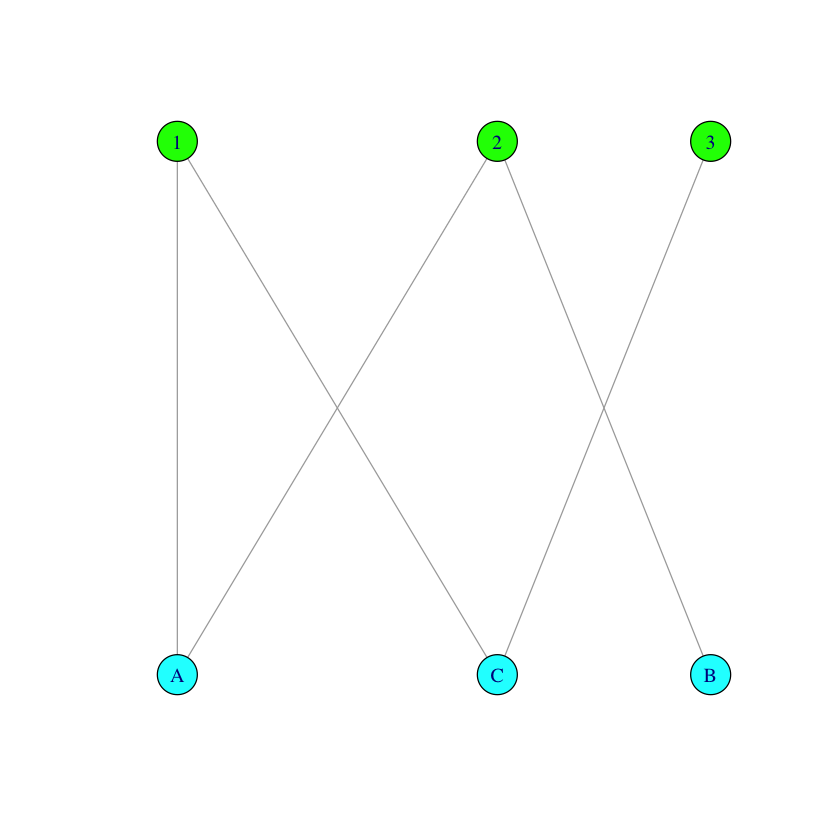

In [57]:
# Plotting bipartite graphs
plot.igraph(g)
plot.igraph(g, layout = layout_as_bipartite,
     vertex.color=c("green","cyan")[V(g)$type+1]) # Try removing the +1 and see what happens to the plot